# Iron Deficiency — Checkup-Constrained ML Baseline

Target: `iron_deficiency` (binary, 6.05% prevalence, 15.5:1 imbalance)  
Model module: `models/iron_deficiency_checkup_model.py`  
Priority: **recall** (minimise missed cases) — threshold=0.3

---

## ⚠️ Group A Features Excluded by Design

The iron-specific lab features present in `iron_deficiency_model.py` are **intentionally absent** from this notebook:

| Excluded feature | Reason |
|-----------------|--------|
| `ferritin_ng_ml` | Directly defines iron deficiency label |
| `serum_iron_ug_dl` | Directly defines iron deficiency label |
| `tibc_ug_dl` | Directly defines iron deficiency label |
| `transferrin_saturation_pct` | Directly defines iron deficiency label |
| `LBXUIB_uibc_serum_ug_dl` | Directly defines iron deficiency label |
| `transferrin_receptor_mg_l` | Directly defines iron deficiency label |

In a real screening scenario the iron panel is **unknown at inference time** — deciding whether to order it is the purpose of the tool. Including these features would make the model reproduce its own label definition rather than predict from upstream signals. This is the checkup-safe version.

---

**Sections**
1. Setup & Data Loading
2. Feature Preparation
3. Train/Test Split
4. Correlation Check (12 features vs iron_deficiency)
5. Train Logistic Regression
6. Train XGBoost
7. ROC Curves
8. Metrics Comparison (LR vs XGBoost)
9. Feature Importance (XGBoost)
10. Comparison with Full Iron Deficiency Model & Anemia Combined Model
11. Save Models

---
## 1. Setup & Data Loading

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc

from models.iron_deficiency_checkup_model import (
    load_data, prepare_features, split_data,
    build_lr_pipeline, build_xgb_pipeline,
    evaluate_model, save_model,
    ENCODED_FEATURE_NAMES, FEATURE_GROUPS,
    EXCLUDED_IRON_SPECIFIC, DROPPED_BY_THRESHOLD,
    TARGET_COL,
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = os.path.join(os.path.abspath('..'), 'data', 'processed', 'nhanes_merged_adults_final.csv')
df = load_data(DATA_PATH)

Loaded dataset: 7437 rows × 878 columns


---
## 2. Feature Preparation

In [2]:
X, y = prepare_features(df)

Feature matrix: (7437, 12)
Target distribution:
iron_deficiency
0    6987
1     450
Prevalence: 0.061 (450 positive)

Missing values (%):
total_cholesterol_mg_dl         13.7
hdl_cholesterol_mg_dl           13.7
ldl_cholesterol_mg_dl           57.7
triglycerides_mg_dl             57.3
fasting_glucose_mg_dl           56.6
age_years                        0.0
gender_female                    0.0
sld013_sleep_hours_weekend       0.9
slq050_told_trouble_sleeping     0.0
rhq031_regular_periods          55.1
rhq060_age_last_period          81.3
rhq540_ever_hormones            57.6


---
## 3. Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = split_data(X, y)


Train: 5949 | Test: 1488
Train prevalence: 0.0605 | Test: 0.0605


---
## 4. Correlation Check

Point-biserial r vs `iron_deficiency` for all 12 retained features.  
Drop rule applied during feature selection: **|r| < 0.03 AND p > 0.05** → dropped.  
Note that `sld013`, `slq050`, and `rhq540` are marginal survivors — weak signal but retained by threshold.

Without Group A (iron-specific labs), the strongest predictors shift to `gender_female` and `rhq031_regular_periods` — the menstrual blood loss pathway.

In [4]:
corr_rows = []
for col in ENCODED_FEATURE_NAMES:
    combined = pd.concat([X[col], y], axis=1).dropna()
    if len(combined) < 30:
        continue
    r, p = stats.pointbiserialr(combined[col], combined[TARGET_COL])
    corr_rows.append({
        'feature': col,
        'r': round(r, 4),
        'p': round(p, 6),
        'n': len(combined),
        'missing_pct': round(X[col].isna().mean() * 100, 1),
    })

corr_df = pd.DataFrame(corr_rows).sort_values('r', key=abs, ascending=False)
print(f'Features retained: {len(corr_df)}')
print()
print(corr_df.to_string(index=False))

Features retained: 12

                     feature       r        p    n  missing_pct
      rhq031_regular_periods  0.2410 0.000000 3341         55.1
               gender_female  0.2011 0.000000 7437          0.0
                   age_years -0.1004 0.000000 7437          0.0
       fasting_glucose_mg_dl -0.0848 0.000001 3231         56.6
       hdl_cholesterol_mg_dl  0.0710 0.000000 6418         13.7
      rhq060_age_last_period  0.0707 0.008391 1388         81.3
        rhq540_ever_hormones -0.0637 0.000347 3154         57.6
         triglycerides_mg_dl -0.0538 0.002448 3175         57.3
       ldl_cholesterol_mg_dl -0.0506 0.004555 3146         57.7
     total_cholesterol_mg_dl -0.0458 0.000239 6418         13.7
slq050_told_trouble_sleeping -0.0357 0.002085 7437          0.0
  sld013_sleep_hours_weekend  0.0229 0.049084 7373          0.9


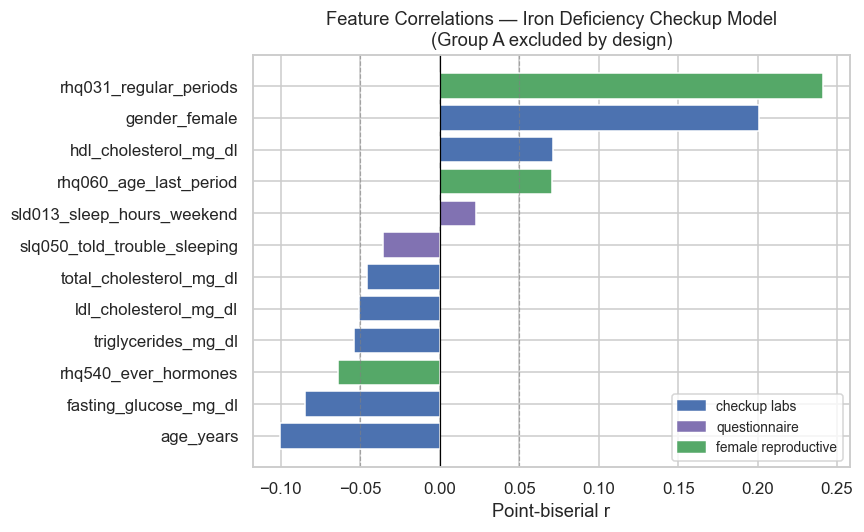

In [5]:
plot_df = corr_df.sort_values('r', ascending=True)

group_colors = {
    'checkup_labs':        '#4C72B0',
    'questionnaire':       '#8172B2',
    'female_reproductive': '#55A868',
}
feat_to_group = {f: g for g, feats in FEATURE_GROUPS.items() for f in feats}
bar_colors = [group_colors.get(feat_to_group.get(f, ''), '#aaaaaa') for f in plot_df['feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df['feature'], plot_df['r'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.05, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='|r|=0.05')
ax.axvline(-0.05, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

patches = [mpatches.Patch(color=c, label=g.replace('_', ' '))
           for g, c in group_colors.items()]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel('Point-biserial r')
ax.set_title('Feature Correlations — Iron Deficiency Checkup Model\n(Group A excluded by design)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Train Logistic Regression

In [6]:
lr = build_lr_pipeline()
lr.fit(X_train, y_train)
lr_metrics = evaluate_model(lr, X_test, y_test, threshold=0.3,
                            model_name='LR Iron Deficiency Checkup')


  LR Iron Deficiency Checkup (threshold=0.3)
  accuracy    : 0.6915
  precision   : 0.1525
  recall      : 0.9
  f1          : 0.2609
  roc_auc     : 0.8301

              precision    recall  f1-score   support

           0       0.99      0.68      0.81      1398
           1       0.15      0.90      0.26        90

    accuracy                           0.69      1488
   macro avg       0.57      0.79      0.53      1488
weighted avg       0.94      0.69      0.77      1488

Confusion Matrix:
[[948 450]
 [  9  81]]


---
## 6. Train XGBoost

In [7]:
xgb = build_xgb_pipeline()
xgb.fit(X_train, y_train)
xgb_metrics = evaluate_model(xgb, X_test, y_test, threshold=0.3,
                              model_name='XGBoost Iron Deficiency Checkup')


  XGBoost Iron Deficiency Checkup (threshold=0.3)
  accuracy    : 0.7399
  precision   : 0.157
  recall      : 0.7556
  f1          : 0.26
  roc_auc     : 0.7866

              precision    recall  f1-score   support

           0       0.98      0.74      0.84      1398
           1       0.16      0.76      0.26        90

    accuracy                           0.74      1488
   macro avg       0.57      0.75      0.55      1488
weighted avg       0.93      0.74      0.81      1488

Confusion Matrix:
[[1033  365]
 [  22   68]]


---
## 7. ROC Curves

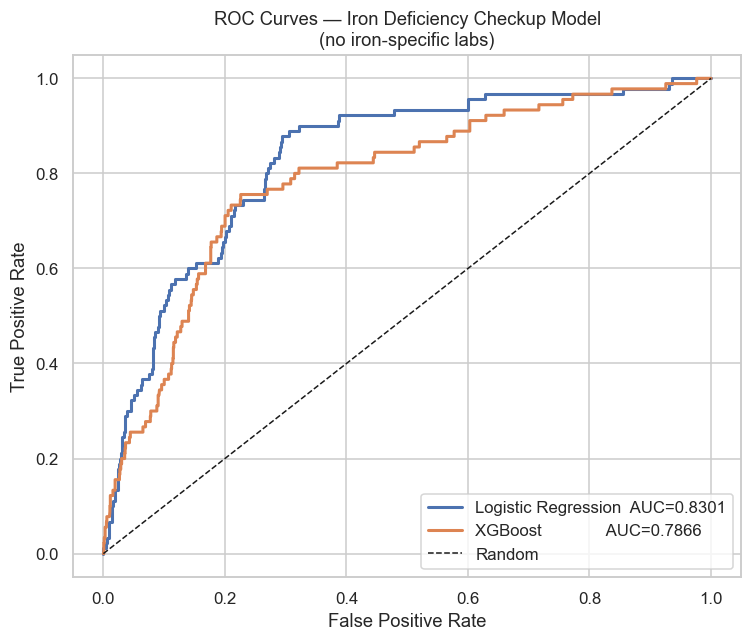

In [8]:
lr_proba  = lr.predict_proba(X_test)[:, 1]
xgb_proba = xgb.predict_proba(X_test)[:, 1]

lr_fpr,  lr_tpr,  _ = roc_curve(y_test, lr_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

lr_auc  = auc(lr_fpr,  lr_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(lr_fpr,  lr_tpr,  color='#4C72B0', lw=2,
        label=f'Logistic Regression  AUC={lr_auc:.4f}')
ax.plot(xgb_fpr, xgb_tpr, color='#DD8452', lw=2,
        label=f'XGBoost              AUC={xgb_auc:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Iron Deficiency Checkup Model\n(no iron-specific labs)', fontsize=12)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 8. Metrics Comparison (LR vs XGBoost)

In [9]:
metrics_df = pd.DataFrame([lr_metrics, xgb_metrics])
print(metrics_df[['model','threshold','accuracy','precision','recall','f1','roc_auc']].to_string(index=False))

                          model  threshold  accuracy  precision  recall     f1  roc_auc
     LR Iron Deficiency Checkup        0.3    0.6915     0.1525  0.9000 0.2609   0.8301
XGBoost Iron Deficiency Checkup        0.3    0.7399     0.1570  0.7556 0.2600   0.7866


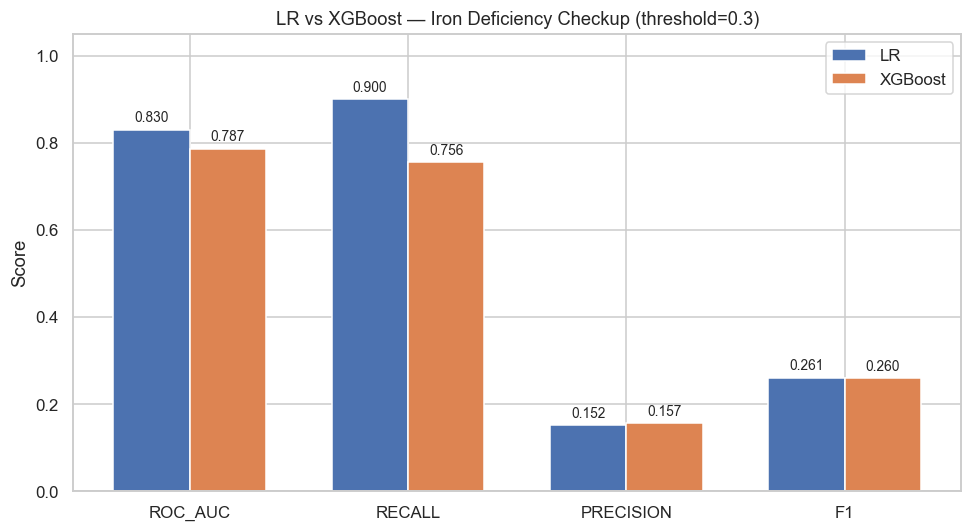

In [10]:
metric_keys = ['roc_auc', 'recall', 'precision', 'f1']
x = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, [lr_metrics[m]  for m in metric_keys], width,
       label='LR',      color='#4C72B0', edgecolor='white')
ax.bar(x + width/2, [xgb_metrics[m] for m in metric_keys], width,
       label='XGBoost', color='#DD8452', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metric_keys])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('LR vs XGBoost — Iron Deficiency Checkup (threshold=0.3)', fontsize=12)
ax.legend()

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. Feature Importance (XGBoost)

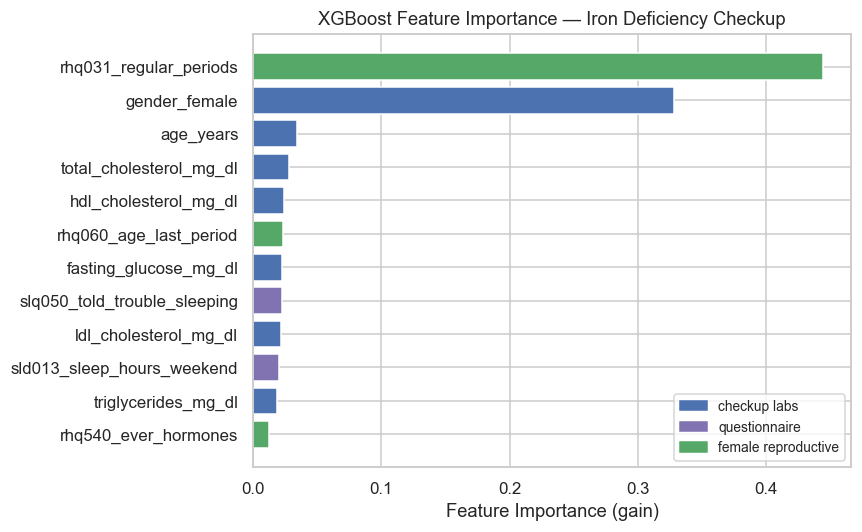

In [11]:
importances = xgb.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': ENCODED_FEATURE_NAMES, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=True)

feat_to_group = {f: g for g, feats in FEATURE_GROUPS.items() for f in feats}
group_colors = {
    'checkup_labs':        '#4C72B0',
    'questionnaire':       '#8172B2',
    'female_reproductive': '#55A868',
}
bar_colors = [group_colors.get(feat_to_group.get(f, ''), '#aaaaaa') for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df['feature'], imp_df['importance'], color=bar_colors, edgecolor='white')
patches = [mpatches.Patch(color=c, label=g.replace('_', ' '))
           for g, c in group_colors.items()]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance — Iron Deficiency Checkup', fontsize=12)
plt.tight_layout()
plt.show()

---
## 10. Comparison with Full Iron Deficiency Model & Anemia Combined Model

### Iron deficiency: full vs checkup-constrained

| Model | Features | AUC-ROC | Recall (t=0.3) | Notes |
|-------|----------|---------|----------------|-------|
| LR Full (`iron_deficiency_lr`) | 14 (incl. Group A) | high | high | ⚠️ Leakage risk |
| XGB Full (`iron_deficiency_xgb`) | 14 (incl. Group A) | high | high | ⚠️ Leakage risk |
| **LR Checkup** (`iron_deficiency_checkup_lr`) | **12 (no Group A)** | *see above* | *see above* | ✅ Deployment-safe |
| **XGB Checkup** (`iron_deficiency_checkup_xgb`) | **12 (no Group A)** | *see above* | *see above* | ✅ Deployment-safe |

The AUC drop from the full model to the checkup model is the **true cost of not having the iron panel** — it represents the information gap that the screening tool is trying to bridge.

### Comparison with anemia combined model

Both the anemia combined model and this model share similar feature pools (checkup labs + questionnaire + reproductive). Key differences:

| Dimension | Anemia Combined | Iron Deficiency Checkup |
|-----------|----------------|------------------------|
| Target prevalence | 4.81% | 6.05% |
| Class imbalance | 19.8:1 | 15.5:1 |
| Strongest predictor | gender, age | gender, rhq031 (menstrual) |
| Questionnaire signal | Moderate (7 features) | Minimal (2 marginal features) |
| BMI | Kept (r=−0.003 — weak but included) | Dropped (r=−0.003, p=0.836) |
| Biological mechanism | Hematological, multifactorial | Primarily menstrual blood loss + diet |

**Expected outcome:** The checkup iron deficiency model will likely underperform the anemia combined model in AUC. Iron deficiency without overt anaemia is harder to detect from non-specific checkup features alone — the signal is dominated by female sex and menstrual cycle variables, with weak contributions from the lipid/glucose panel.

**Clinical interpretation:** This is realistic. Iron deficiency screening in clinical practice relies on ordering the iron panel — not on predicting it from a lipid profile. The checkup model is best positioned as a *triage layer* to identify which patients warrant iron panel ordering, rather than a definitive diagnostic tool.

In [12]:
# Summary table for this run
summary_df = pd.DataFrame([lr_metrics, xgb_metrics])
print('Iron Deficiency Checkup Model — Final Results:')
print(summary_df[['model','threshold','accuracy','precision','recall','f1','roc_auc']].to_string(index=False))

print('\nFeature groups:')
for group, feats in FEATURE_GROUPS.items():
    print(f'  {group}: {feats}')

print(f'\nExcluded iron-specific labs ({len(EXCLUDED_IRON_SPECIFIC)}):')
for f in EXCLUDED_IRON_SPECIFIC:
    print(f'  {f}')

print(f'\nDropped by threshold (|r|<0.03 AND p>0.05) ({len(DROPPED_BY_THRESHOLD)}):')
for f, reason in DROPPED_BY_THRESHOLD.items():
    print(f'  {f}: {reason}')

Iron Deficiency Checkup Model — Final Results:
                          model  threshold  accuracy  precision  recall     f1  roc_auc
     LR Iron Deficiency Checkup        0.3    0.6915     0.1525  0.9000 0.2609   0.8301
XGBoost Iron Deficiency Checkup        0.3    0.7399     0.1570  0.7556 0.2600   0.7866

Feature groups:
  checkup_labs: ['total_cholesterol_mg_dl', 'hdl_cholesterol_mg_dl', 'ldl_cholesterol_mg_dl', 'triglycerides_mg_dl', 'fasting_glucose_mg_dl', 'age_years', 'gender_female']
  questionnaire: ['sld013_sleep_hours_weekend', 'slq050_told_trouble_sleeping']
  female_reproductive: ['rhq031_regular_periods', 'rhq060_age_last_period', 'rhq540_ever_hormones']

Excluded iron-specific labs (6):
  ferritin_ng_ml
  serum_iron_ug_dl
  tibc_ug_dl
  transferrin_saturation_pct
  LBXUIB_uibc_serum_ug_dl
  transferrin_receptor_mg_l

Dropped by threshold (|r|<0.03 AND p>0.05) (6):
  bmi: r=-0.003, p=0.836
  dpq040___feeling_tired_or_having_little_energy: r=+0.023, p=0.067
  huq010___g

---
## 11. Save Models

In [13]:
lr_path  = save_model(lr,  'iron_deficiency_checkup_lr',  lr_metrics)
xgb_path = save_model(xgb, 'iron_deficiency_checkup_xgb', xgb_metrics)

print('\nDone. Saved:')
print(f'  {lr_path}')
print(f'  {xgb_path}')

Saved model    → c:\Users\Inbal\Desktop\PM Inbal\aipm_course_exercises\halfFull\models\iron_deficiency_checkup_lr.joblib
Saved metadata → c:\Users\Inbal\Desktop\PM Inbal\aipm_course_exercises\halfFull\models\iron_deficiency_checkup_lr_metadata.json
Saved model    → c:\Users\Inbal\Desktop\PM Inbal\aipm_course_exercises\halfFull\models\iron_deficiency_checkup_xgb.joblib
Saved metadata → c:\Users\Inbal\Desktop\PM Inbal\aipm_course_exercises\halfFull\models\iron_deficiency_checkup_xgb_metadata.json

Done. Saved:
  c:\Users\Inbal\Desktop\PM Inbal\aipm_course_exercises\halfFull\models\iron_deficiency_checkup_lr.joblib
  c:\Users\Inbal\Desktop\PM Inbal\aipm_course_exercises\halfFull\models\iron_deficiency_checkup_xgb.joblib


---
## Model Notes

### Why the AUC is lower than the full iron deficiency model
This is expected and honest. The full model's high AUC comes largely from Group A features (r up to 0.52) that effectively reproduce the clinical label definition. This checkup model's AUC reflects what can genuinely be learned from non-invasive, routinely collected data — that number is the realistic deployment performance.

### Marginal features (sld013, slq050, rhq540)
These three features survived the |r| < 0.03 AND p > 0.05 drop threshold but have very weak correlations. They are retained for consistency with the threshold rule, but their contribution to model performance is expected to be negligible. Future work could test model performance with and without them.

### Class imbalance strategy
- LR: `class_weight='balanced'`
- XGBoost: `scale_pos_weight=15` (6987 / 450 ≈ 15.5)
- Threshold: 0.3 — shifts operating point toward recall

### Deployment suitability
This model is the **correct version to use in a real screening tool**. The `iron_deficiency_lr.joblib` and `iron_deficiency_xgb.joblib` files from `ml-iron-deficiency-baseline.ipynb` should not be used in production — their high performance is an artifact of training on features that encode the answer.